# Composing GPT Model Architectural Components

In [15]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) ## projecting vocabulary to embeddings dimensional space.
        self.pos_emb = nn.Embedding(cfg["context_window_size"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) ## projecting embeddings to vocabulary_size dimensional space.

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        ## represents the scores for all tokens in the vocabulary, higher score implies higher chances of being next token.
        logits = self.out_head(x)
        
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

## DummyGPTModel Placeholder Inference

<img src="images/gpt-model-overview.png" width="30%"/>

In [19]:
import torch
import tiktoken

torch.manual_seed(123)

GPT_CONFIG_124M = {
    "vocab_size": 50257,          # Vocabulary size
    "context_window_size": 1024,  # Context window sizew
    "emb_dim": 768,               # Embedding dimension
    "n_heads": 12,                # Number of attention heads
    "n_layers": 12,               # Number of layers
    "drop_rate": 0.1,             # Dropout rate
    "qkv_bias": False             # Query-Key-Value bias
}

tokenizer = tiktoken.get_encoding("gpt2")

training_example_1 = torch.tensor(tokenizer.encode("Every effort moves you"))
training_example_2 = torch.tensor(tokenizer.encode("Every day holds a"))

training_examples_batch = []
training_examples_batch.append(training_example_1)
training_examples_batch.append(training_example_2)
training_examples_batch = torch.stack(training_examples_batch, dim=0)

gpt_model = DummyGPTModel(cfg = GPT_CONFIG_124M)
logits = gpt_model(training_examples_batch)

print(f"logits.shape: {logits.shape}\n")
print(f"Likelihood scores for each token: {logits}")

logits.shape: torch.Size([2, 4, 50257])

Likelihood scores for each token: tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


**Note:** _The logits.shape is `2 x 4 x 50257` i.e 2 training examples, each example containing 4 tokens in a context_window, 50257 values representing likelihood scores for all tokens in a vocabulary to be a next token._

## Normalization Layer

Understand normalization using random mock inputs and then apply it to actual training examples.

<img src="images/normalization-layer.png" width="30%"/>

In [89]:
torch.manual_seed(123)
torch.set_printoptions(sci_mode=False)

# 2 examples, each having 5 tokens
examples_batch = torch.randn(2, 5)

# Map 5 tokens values into 6 hidden output values.
some_hidden_nn_layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
hidden_out = some_hidden_nn_layer(examples_batch)
print(f"hidden_out: {hidden_out}\n")

# Calculate Mean & Variance on existing `hidden_out`
mean = hidden_out.mean(dim=-1, keepdim=True)
variance = hidden_out.var(dim=-1, keepdim=True)
print(f"Original mean of hidden layer output: {mean}\n")
print(f"Original variance of hidden layer output: {variance}\n")

# Calculate Mean & Variance on normalized version of `hidden_out`
normed = (hidden_out - mean) / torch.sqrt(variance)
print(f"Normalized mean of hidden layer output: {normed.mean():.3f}\n")
print(f"Normalized variance of hidden layer output: {normed.var():.3f}\n")

hidden_out: tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

Original mean of hidden layer output: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

Original variance of hidden layer output: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

Normalized mean of hidden layer output: -0.000

Normalized variance of hidden layer output: 0.909



## Abstraction of Normalization Layer

In [90]:
class NormalizationLayer(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**Note:**
- `eps` is to avoid divide by zero error.
- `scale` is learn appropriate weights to make the normalization operation (division by variance) fruitful either by undoing it altogether or adjusting it appropriately.
- `shift` is learn appropriate weights to make the normalization operation (subtraction by mean) fruitful either by undoing it altogether or adjusting it appropriately.

## Use the Normalization Layer

In [101]:
torch.manual_seed(123)
torch.set_printoptions(sci_mode=False)

examples_count = 2 
hidden_layer_input_dim = 5
hidden_layer_output_dim = 6

# 2 examples, each having 5 tokens passed, through a hidden NN hidden layer which results in 6 values.
examples_batch = torch.randn(examples_count, hidden_layer_input_dim)
some_hidden_nn_layer = nn.Sequential(nn.Linear(hidden_layer_input_dim, hidden_layer_output_dim), nn.ReLU())
hidden_layer_output = some_hidden_nn_layer(examples_batch)

# Normalized the output values of hidden layer.
normalization_layer = NormalizationLayer(hidden_layer_output_dim)
hidden_layer_normalized_output = normalization_layer(hidden_layer_output)

hidden_layer_normalized_output

tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)

In [102]:
normalized_mean = hidden_layer_normalized_output.mean(dim=-1, keepdim=True)
normalized_mean

tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)

In [103]:
normalized_variance = hidden_layer_normalized_output.var(dim=-1, keepdim=True, unbiased=False)
normalized_variance

tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)

## GELU Activation

In [104]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

### Visualize GELU vs ReLU

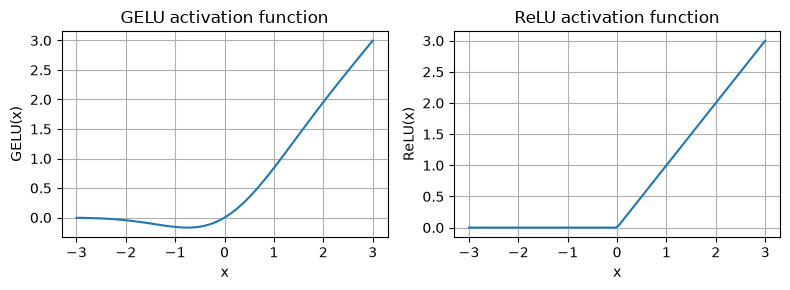

In [105]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

**Note:** _Due to smoothness in GELU activation function comapred to ReLU activation function, which leads to effective properties during gradient optimizations (learning)._

## Feedforward Module

In [106]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

**Note:** _First `nn.Linear` transforms input vectors in `emb_dim` space into 4 times of its dimensional space and then pass through activation function and then trasnforms back the vectors to `emb_dim` space._

### Use Feedforward Module

In [107]:
# 2 input sequences (training examples), each having 3 tokens and each token is represented as 768 embedding dimensions.
x = torch.rand(2, 3, 768)

feed_fwd_nn = FeedForward(GPT_CONFIG_124M)
out = feed_fwd_nn(x)

print(out.shape)

torch.Size([2, 3, 768])


In [108]:
# All layers of a feed forward neural network.
feed_fwd_nn.layers

Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GELU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
)

In [110]:
# The weights of first layer of the feed forward neural network will be the weights whose values represents the trained neural network after training.
feed_fwd_nn.layers[0].weight 

Parameter containing:
tensor([[-0.0300, -0.0290, -0.0226,  ..., -0.0355,  0.0279,  0.0341],
        [ 0.0151, -0.0119, -0.0048,  ..., -0.0076, -0.0272, -0.0249],
        [-0.0142,  0.0070, -0.0113,  ..., -0.0136, -0.0194, -0.0352],
        ...,
        [ 0.0284,  0.0199,  0.0137,  ..., -0.0346,  0.0047, -0.0215],
        [ 0.0311, -0.0194,  0.0062,  ...,  0.0133, -0.0267,  0.0131],
        [-0.0200,  0.0287, -0.0229,  ..., -0.0259,  0.0264,  0.0009]],
       requires_grad=True)

## Shortcut Connection

If the neural network `f(x)` does not learn anything useful then input is fed as a shortcut as well to keep the signal `f(x) + x`.

This can happen due to vanishing gradient problem and by adding a shortcut connection of input on top of out of neural network you maintain the gradient signal i.e. making sure network still learns something useful.


In [113]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

## Usage without Shortcut Layer

In [122]:
torch.manual_seed(123)
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1.0, 0.0, -1.0]])

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011158833047375
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


## Usage with Shortcut Layer

In [121]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896992564201355
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


## Prepare Transformer Block

In [127]:
import sys 
sys.path.append("../..")
from attention_mechanism_module import MultiHeadAttention  # or whatever you define

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [ ]:
MultiHeadAttention()